Plotting System Metrics

1. Plotting TPS metrics...


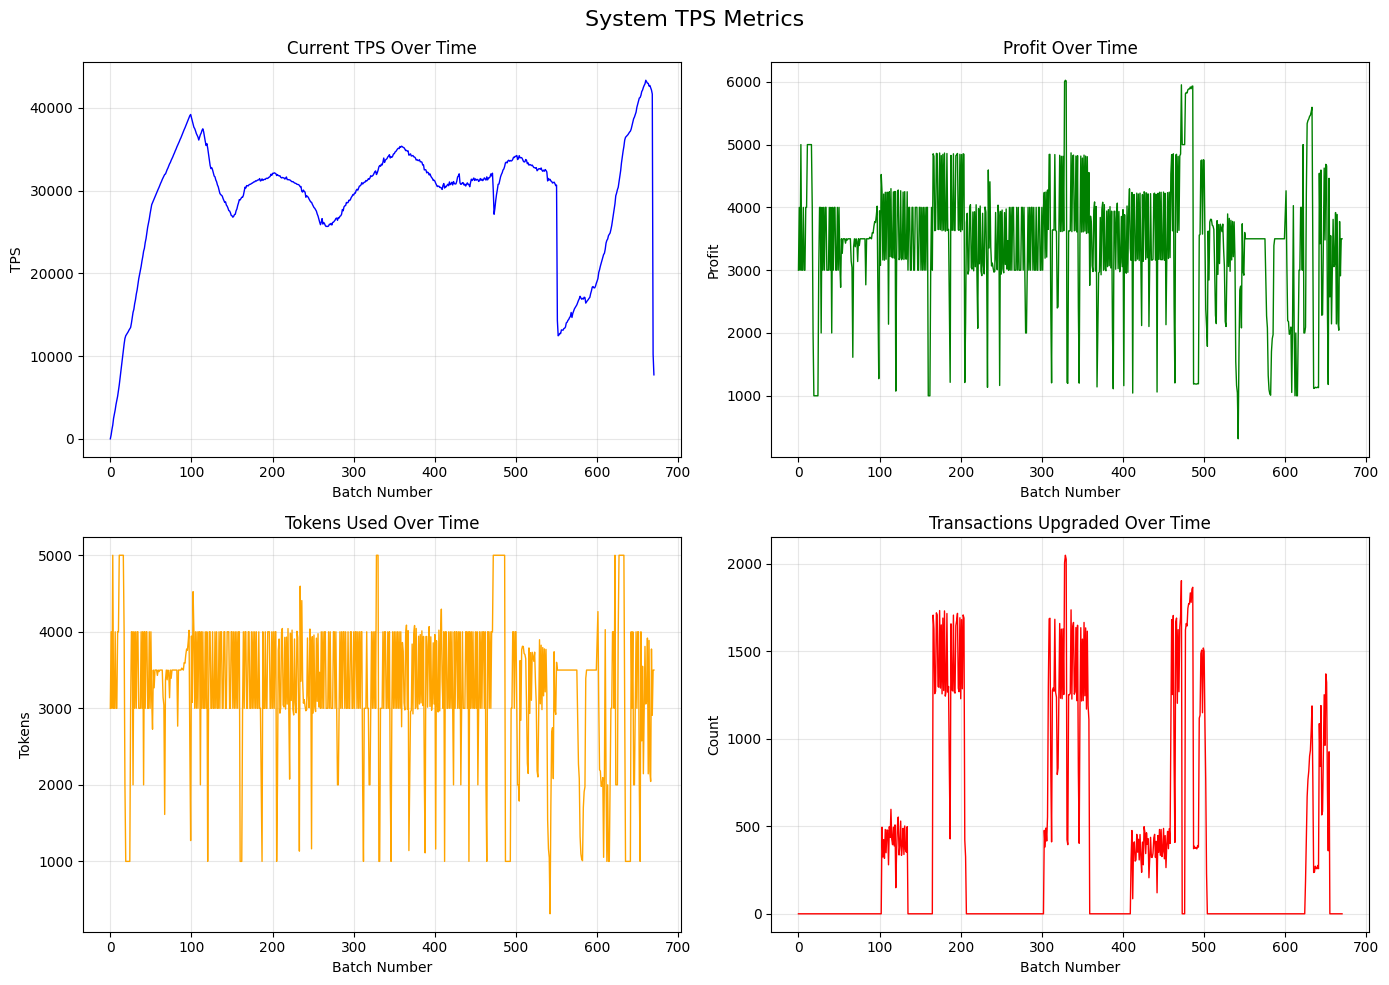


2. Plotting Incoming Transaction Rate...


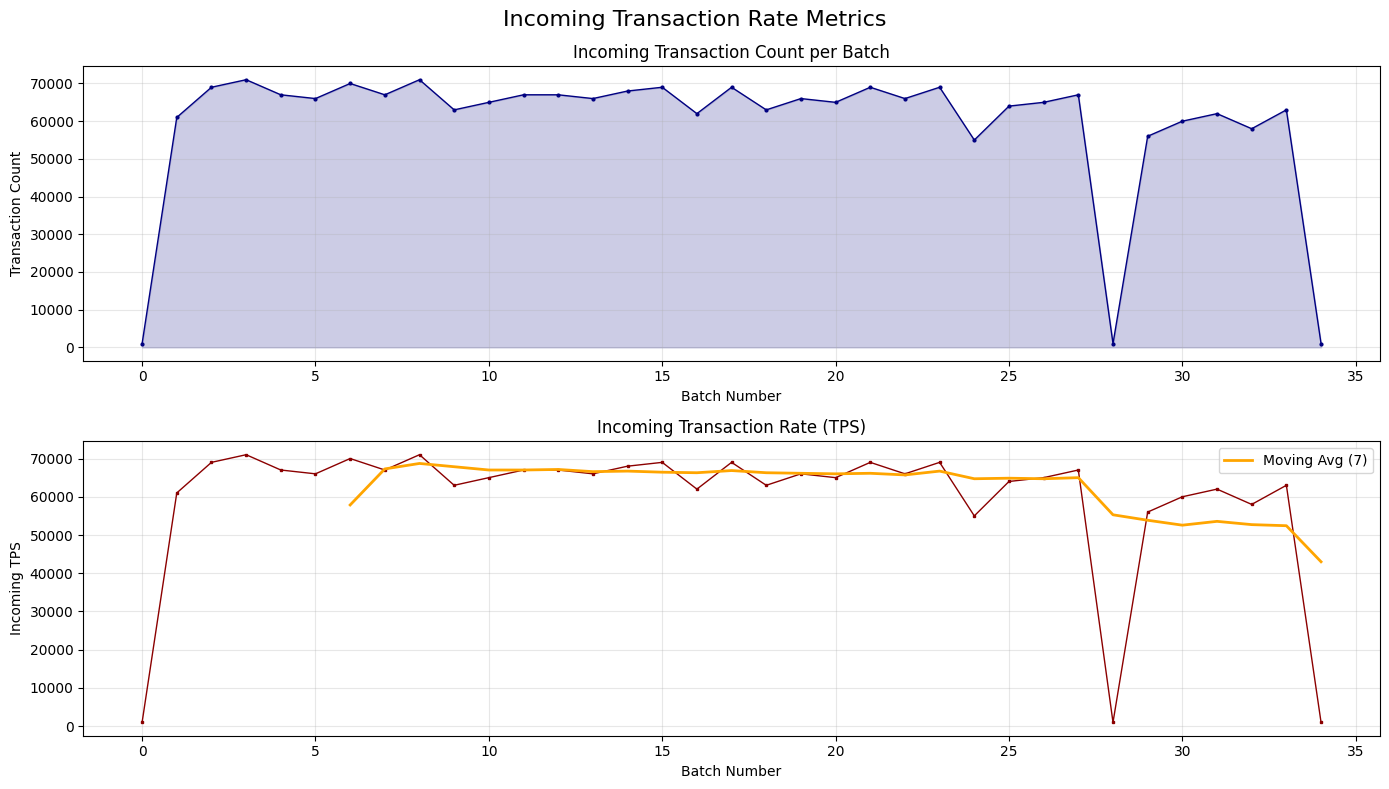


3. Plotting Backlog...


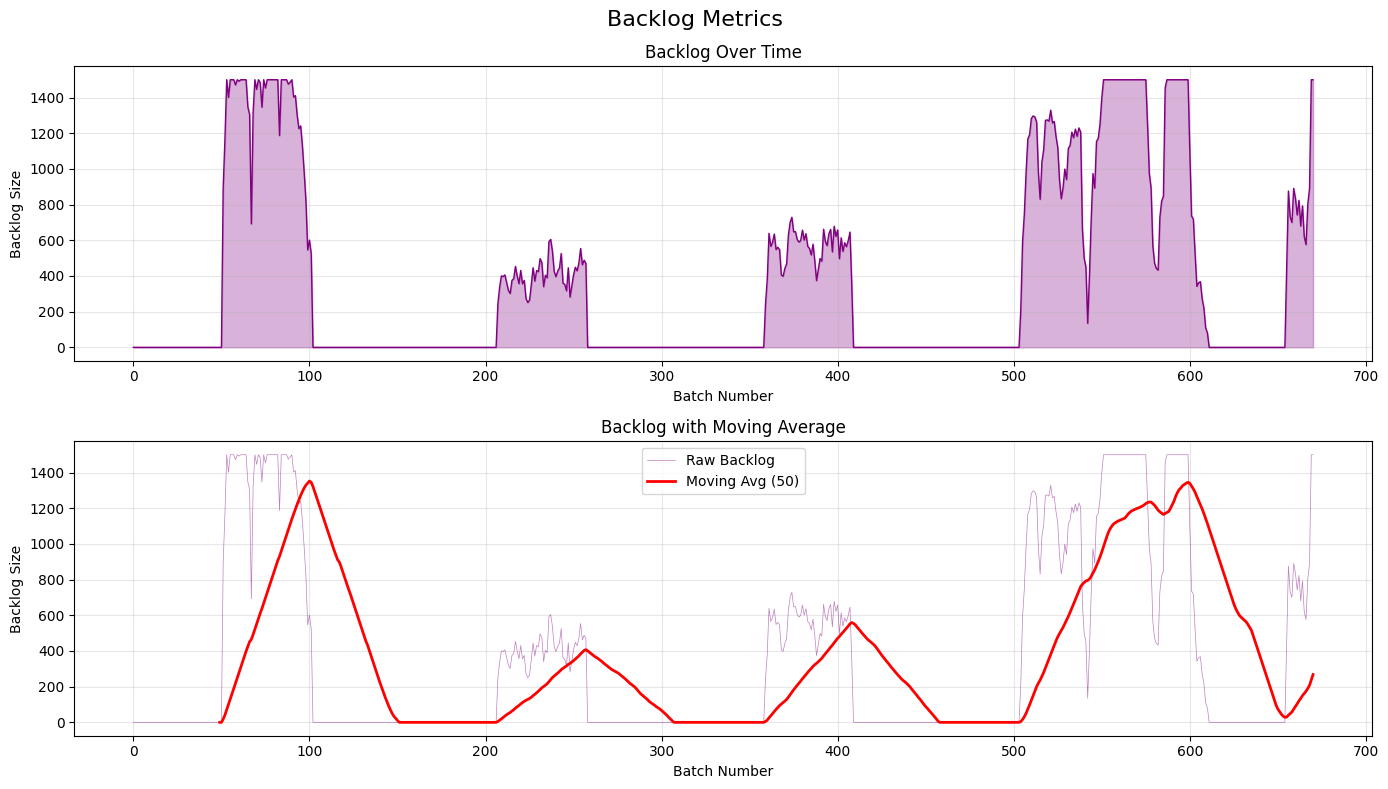


4. Plotting WriteConcern Frequency...


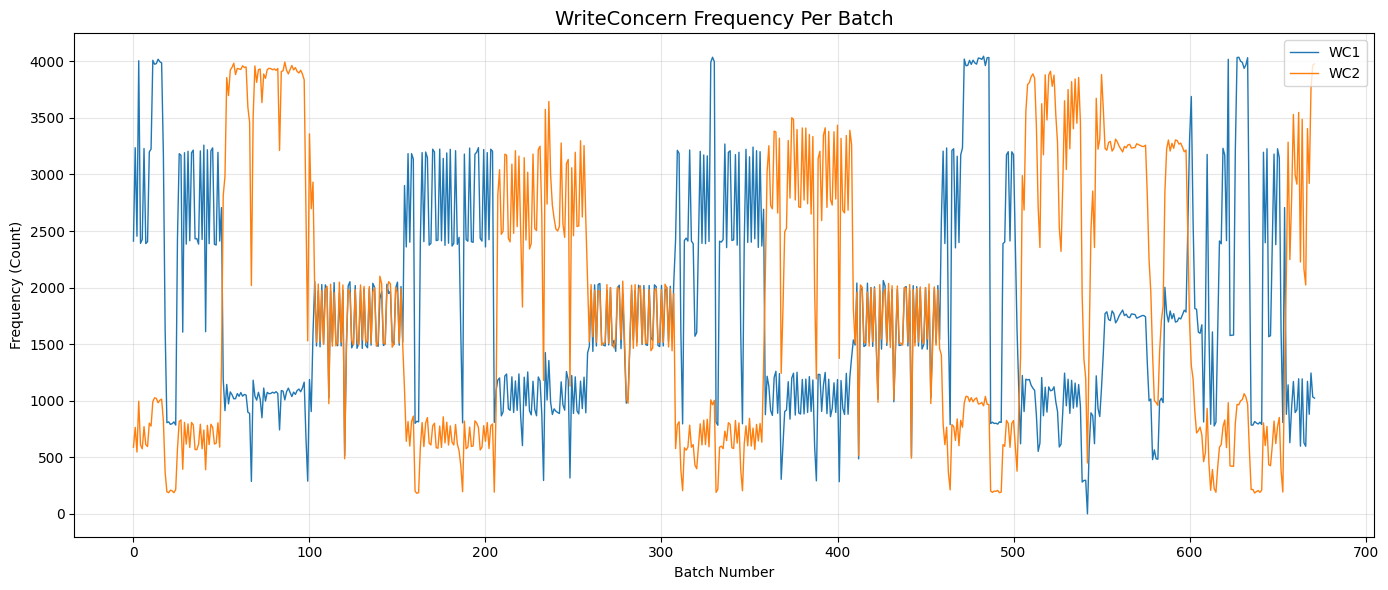


5. Plotting WriteConcern TPS...


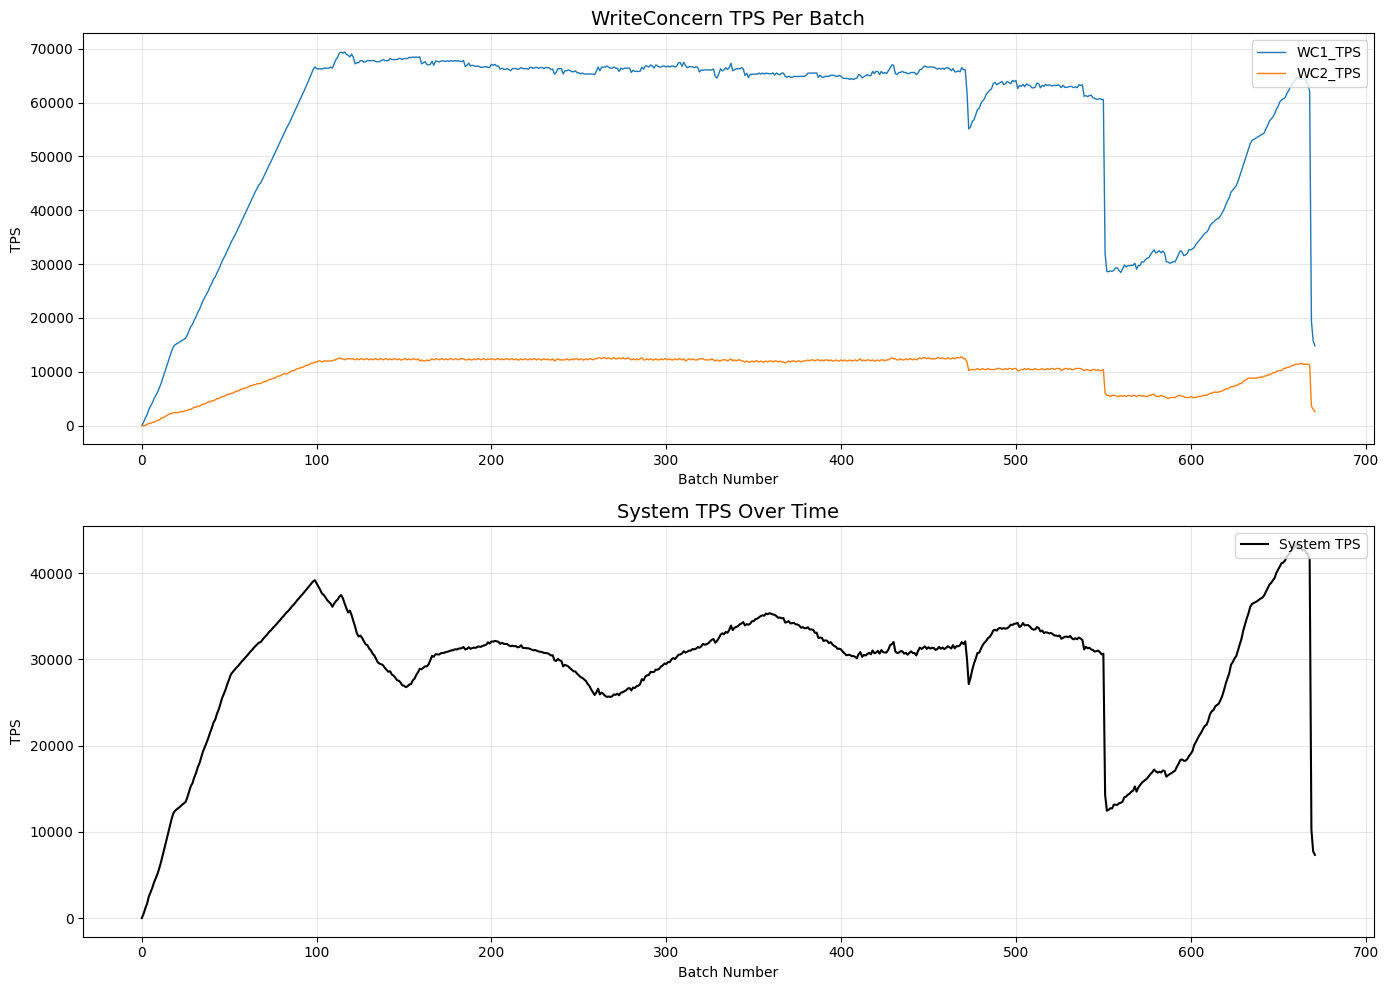


6. Plotting Final Batch Average TPS...


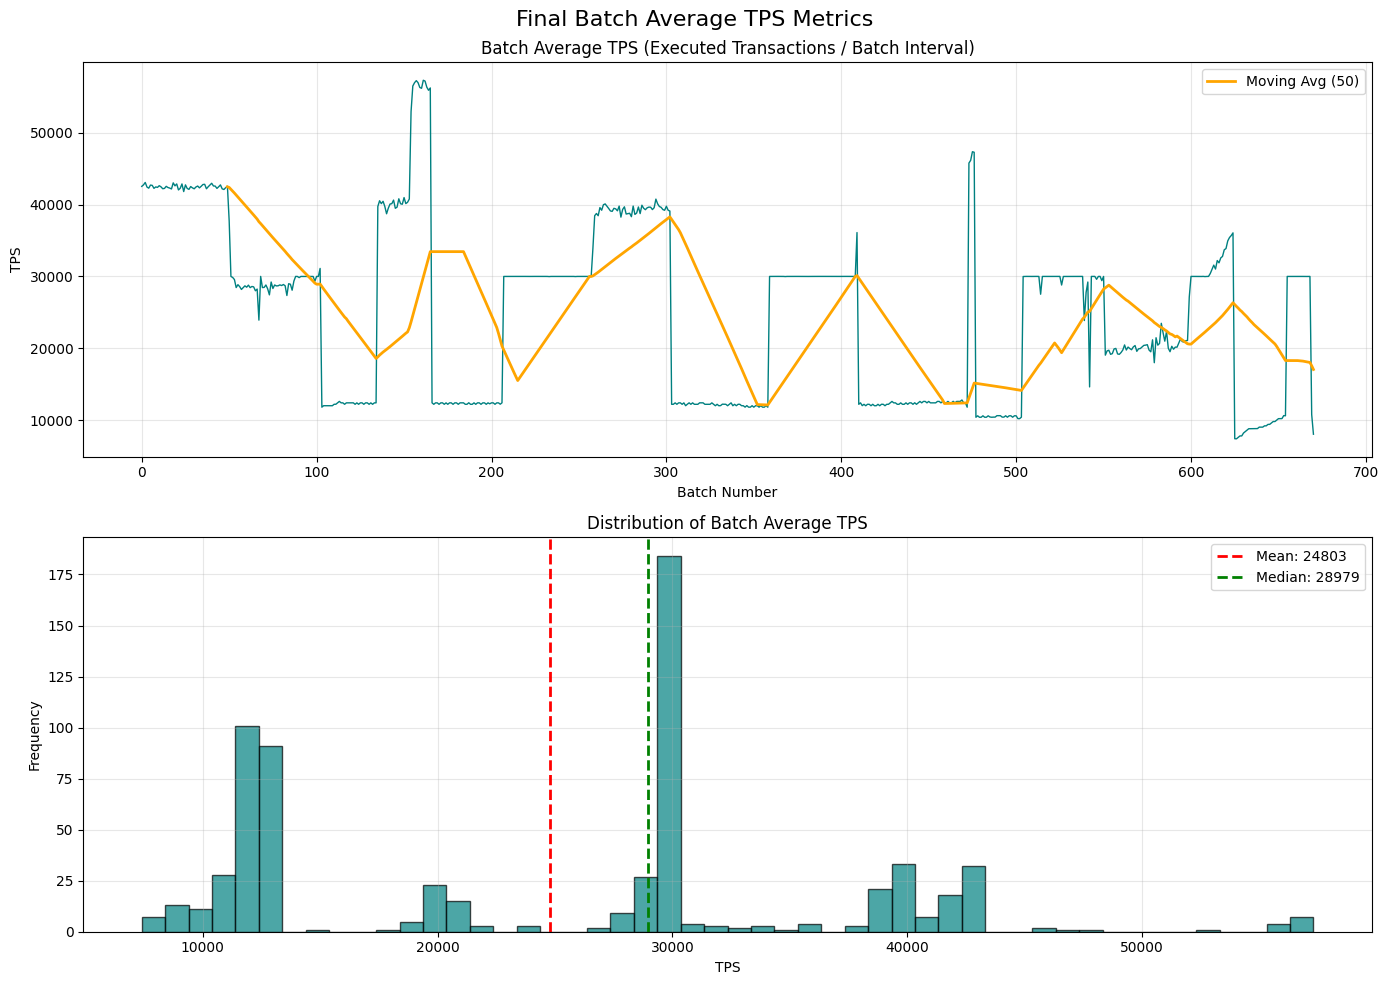


📊 Batch Average TPS Statistics:
   Mean: 24803.22
   Median: 28979.05
   Min: 7405.75
   Max: 57287.31
   Std Dev: 11899.83

7. Plotting Combined Dashboard...


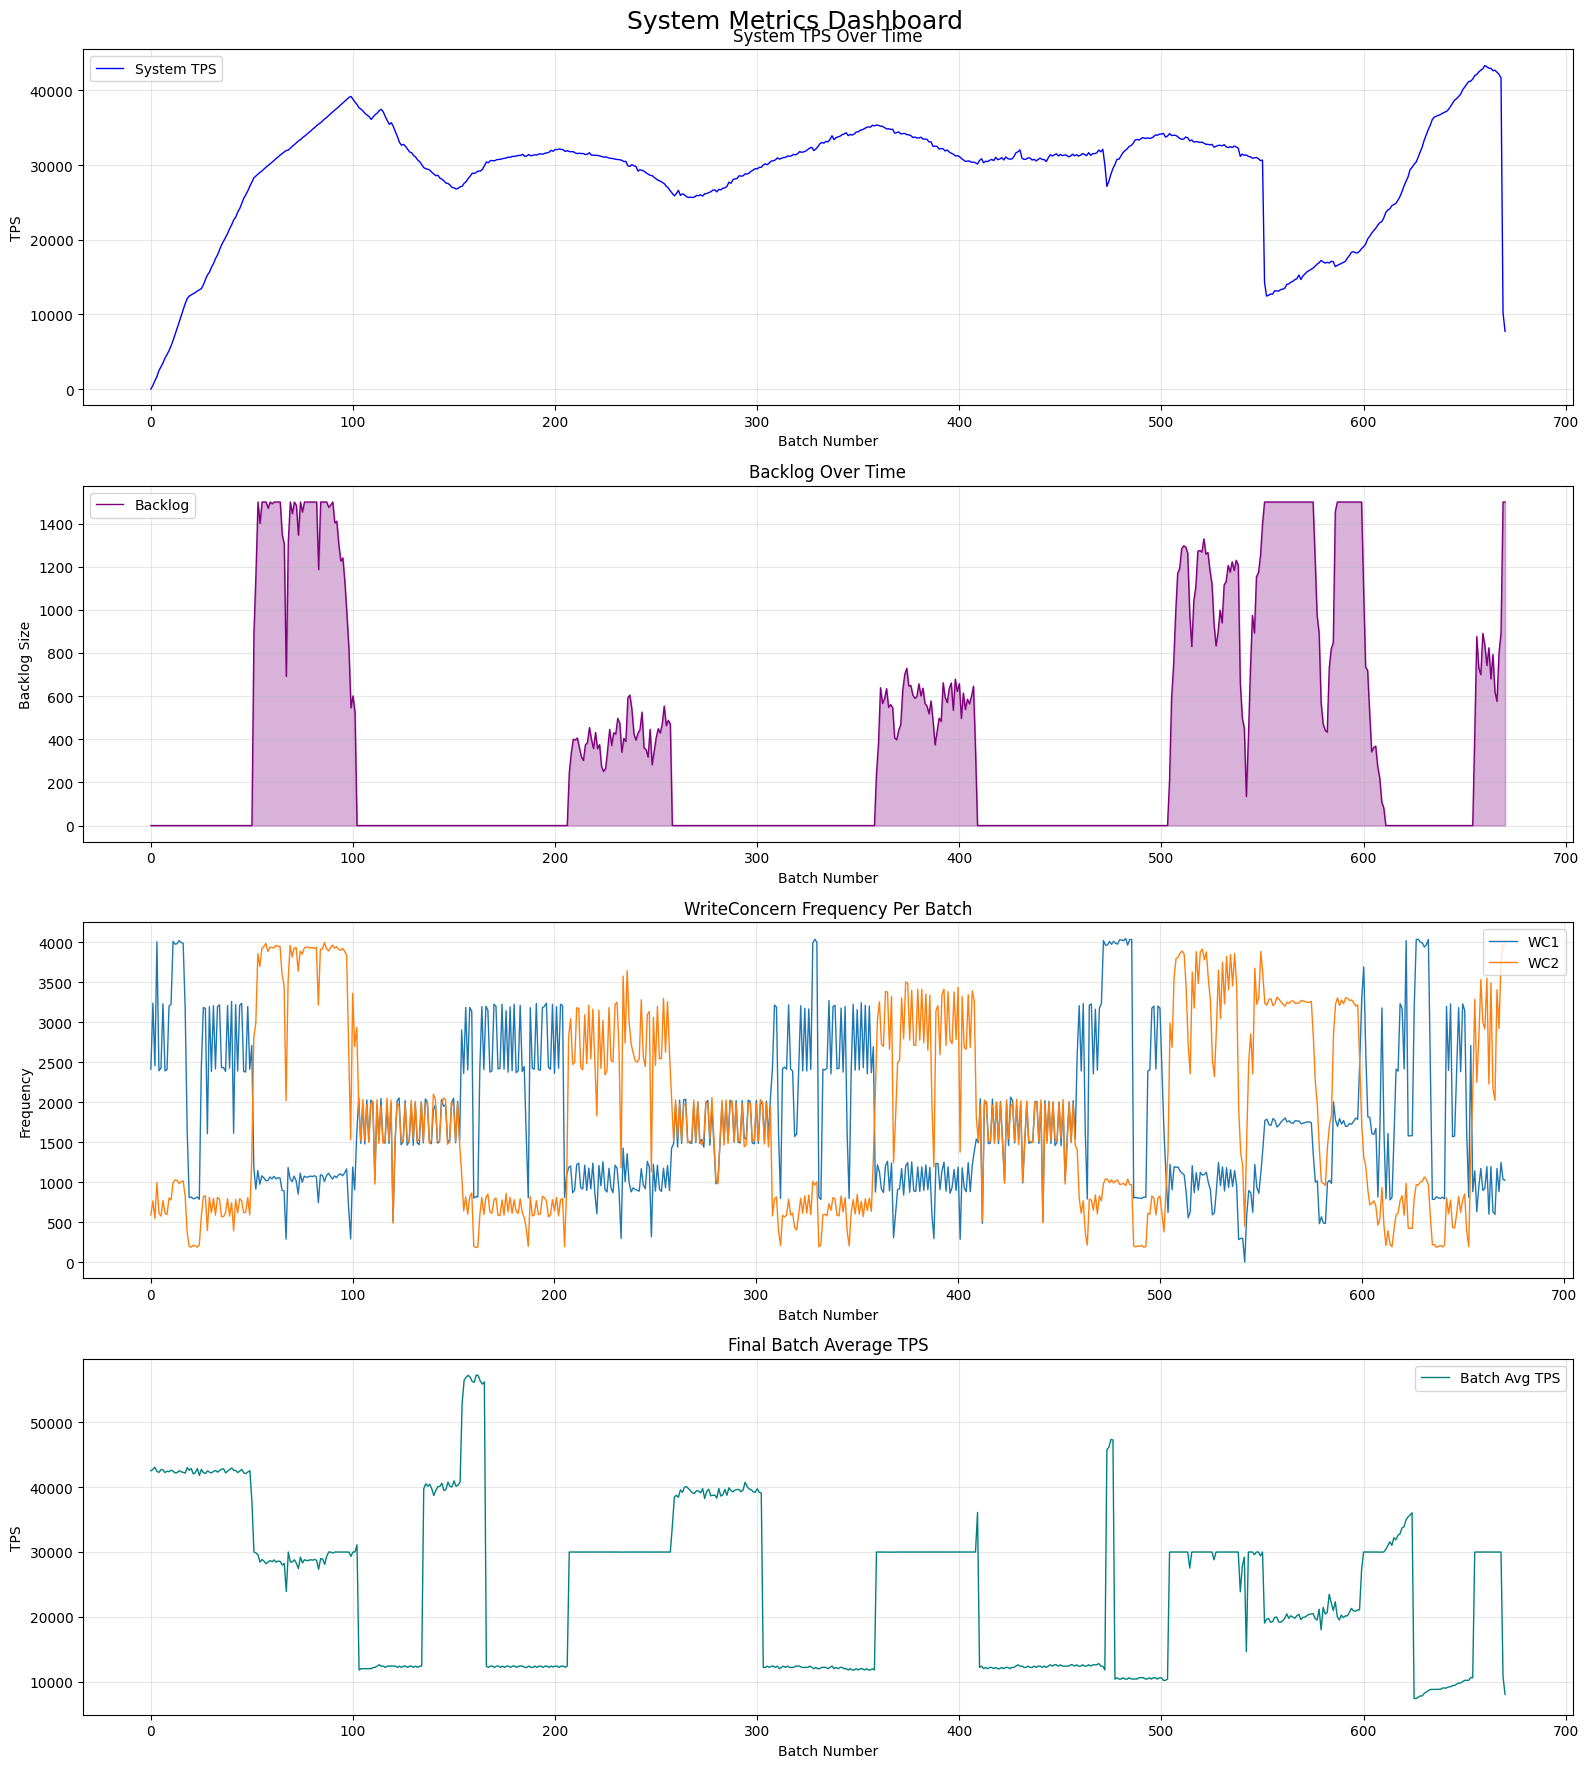


8. Plotting Stacked Area Chart...


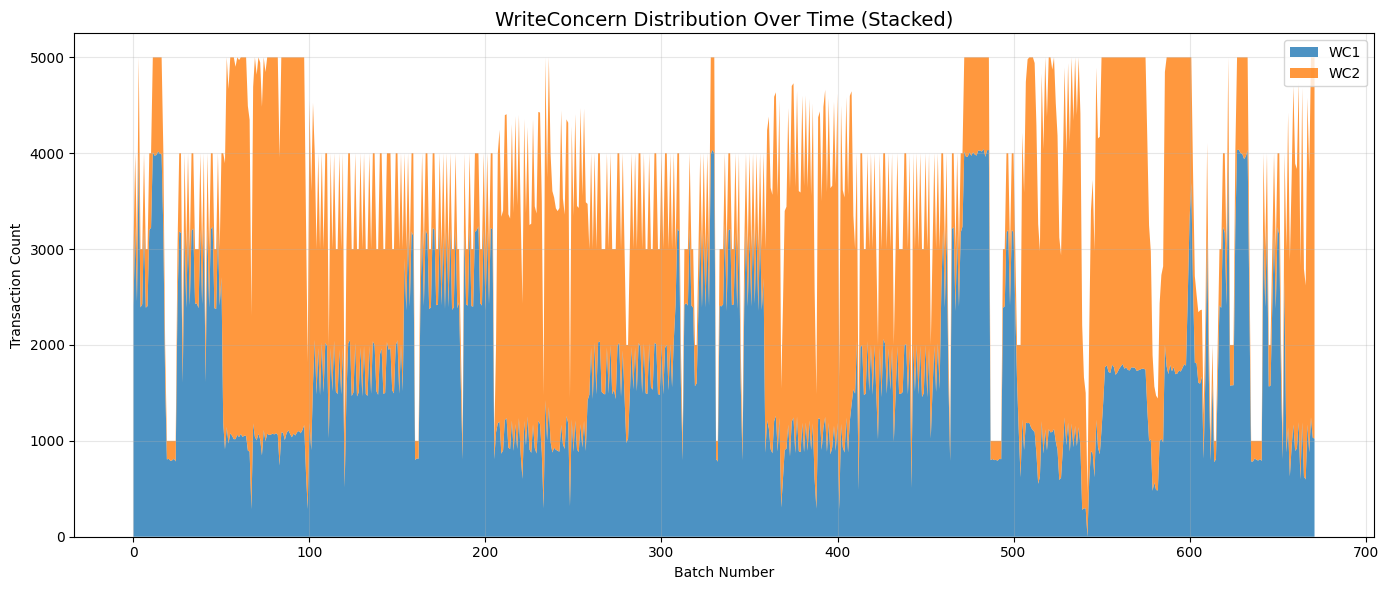


All plots generated successfully!


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set the directory where CSV files are located
CSV_DIR = "."  # Change this if CSVs are in a different directory

def plot_tps():
    """Plot system TPS metrics from tps.csv"""
    filepath = os.path.join(CSV_DIR, "tps.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('System TPS Metrics', fontsize=16)
    
    # Plot Current TPS
    axes[0, 0].plot(df.index, df['CurrentTPS'], color='blue', linewidth=1)
    axes[0, 0].set_title('Current TPS Over Time')
    axes[0, 0].set_xlabel('Batch Number')
    axes[0, 0].set_ylabel('TPS')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot Profit
    axes[0, 1].plot(df.index, df['Profit'], color='green', linewidth=1)
    axes[0, 1].set_title('Profit Over Time')
    axes[0, 1].set_xlabel('Batch Number')
    axes[0, 1].set_ylabel('Profit')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot Tokens Used
    axes[1, 0].plot(df.index, df['TokensUsed'], color='orange', linewidth=1)
    axes[1, 0].set_title('Tokens Used Over Time')
    axes[1, 0].set_xlabel('Batch Number')
    axes[1, 0].set_ylabel('Tokens')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot Transactions Upgraded
    axes[1, 1].plot(df.index, df['TransactionsUpgraded'], color='red', linewidth=1)
    axes[1, 1].set_title('Transactions Upgraded Over Time')
    axes[1, 1].set_xlabel('Batch Number')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_incoming_transaction_rate():
    """Plot incoming transaction rate from incoming_transaction_rate.csv"""
    filepath = os.path.join(CSV_DIR, "incoming_transaction_rate.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Incoming Transaction Rate Metrics', fontsize=16)
    
    # Plot Incoming Transaction Count per batch
    axes[0].plot(df.index, df['IncomingTransactionCount'], color='navy', linewidth=1, marker='o', markersize=2)
    axes[0].set_title('Incoming Transaction Count per Batch')
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('Transaction Count')
    axes[0].grid(True, alpha=0.3)
    axes[0].fill_between(df.index, df['IncomingTransactionCount'], alpha=0.2, color='navy')
    
    # Plot Incoming TPS
    axes[1].plot(df.index, df['IncomingTPS'], color='darkred', linewidth=1, marker='s', markersize=2)
    axes[1].set_title('Incoming Transaction Rate (TPS)')
    axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Incoming TPS')
    axes[1].grid(True, alpha=0.3)
    
    # Add rolling average for TPS
    window_size = min(20, len(df) // 5) if len(df) > 5 else 1
    if window_size > 1:
        df['IncomingTPS_MA'] = df['IncomingTPS'].rolling(window=window_size).mean()
        axes[1].plot(df.index, df['IncomingTPS_MA'], color='orange', linewidth=2, 
                    label=f'Moving Avg ({window_size})')
        axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_backlog():
    """Plot backlog metrics from backlog.csv"""
    filepath = os.path.join(CSV_DIR, "backlog.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Backlog Metrics', fontsize=16)
    
    # Plot Backlog over time
    axes[0].plot(df.index, df['Backlog'], color='purple', linewidth=1)
    axes[0].set_title('Backlog Over Time')
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('Backlog Size')
    axes[0].grid(True, alpha=0.3)
    axes[0].fill_between(df.index, df['Backlog'], alpha=0.3, color='purple')
    
    # Plot Backlog with rolling average
    window_size = min(50, len(df) // 10) if len(df) > 10 else 1
    if window_size > 1:
        df['Backlog_MA'] = df['Backlog'].rolling(window=window_size).mean()
        axes[1].plot(df.index, df['Backlog'], color='purple', linewidth=0.5, alpha=0.5, label='Raw Backlog')
        axes[1].plot(df.index, df['Backlog_MA'], color='red', linewidth=2, label=f'Moving Avg ({window_size})')
        axes[1].legend()
    else:
        axes[1].plot(df.index, df['Backlog'], color='purple', linewidth=1)
    axes[1].set_title('Backlog with Moving Average')
    axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Backlog Size')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_writeconcern_frequency():
    """Plot writeConcern frequency from writeconcern_frequency.csv"""
    filepath = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    # Get WC columns (exclude Timestamp and TotalInBatch)
    wc_columns = [col for col in df.columns if col.startswith('WC')]
    
    plt.figure(figsize=(14, 6))
    
    for col in wc_columns:
        plt.plot(df.index, df[col], label=col, linewidth=1)
    
    plt.title('WriteConcern Frequency Per Batch', fontsize=14)
    plt.xlabel('Batch Number')
    plt.ylabel('Frequency (Count)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_writeconcern_tps():
    """Plot writeConcern TPS from writeconcern_tps.csv"""
    filepath = os.path.join(CSV_DIR, "writeconcern_tps.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    # Get WC TPS columns (exclude Timestamp and SystemTPS)
    wc_tps_columns = [col for col in df.columns if col.startswith('WC') and col.endswith('_TPS')]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot individual WC TPS
    for col in wc_tps_columns:
        axes[0].plot(df.index, df[col], label=col, linewidth=1)
    
    axes[0].set_title('WriteConcern TPS Per Batch', fontsize=14)
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('TPS')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Plot System TPS for comparison
    if 'SystemTPS' in df.columns:
        axes[1].plot(df.index, df['SystemTPS'], color='black', linewidth=1.5, label='System TPS')
        axes[1].set_title('System TPS Over Time', fontsize=14)
        axes[1].set_xlabel('Batch Number')
        axes[1].set_ylabel('TPS')
        axes[1].legend(loc='upper right')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_batch_avg_tps():
    """Plot batch average TPS from final_batch_avg_tps_log.csv"""
    filepath = os.path.join(CSV_DIR, "final_batch_avg_tps_log.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    # CSV has no header, columns are: Timestamp, BatchAvgTPS
    df = pd.read_csv(filepath, header=None, names=['Timestamp', 'BatchAvgTPS'])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Final Batch Average TPS Metrics', fontsize=16)
    
    # Plot Batch Average TPS
    axes[0].plot(df.index, df['BatchAvgTPS'], color='teal', linewidth=1)
    axes[0].set_title('Batch Average TPS (Executed Transactions / Batch Interval)')
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('TPS')
    axes[0].grid(True, alpha=0.3)
    
    # Add rolling average
    window_size = min(50, len(df) // 10) if len(df) > 10 else 1
    if window_size > 1:
        df['BatchAvgTPS_MA'] = df['BatchAvgTPS'].rolling(window=window_size).mean()
        axes[0].plot(df.index, df['BatchAvgTPS_MA'], color='orange', linewidth=2, 
                    label=f'Moving Avg ({window_size})')
        axes[0].legend()
    
    # Plot histogram of TPS distribution
    axes[1].hist(df['BatchAvgTPS'], bins=50, color='teal', alpha=0.7, edgecolor='black')
    axes[1].set_title('Distribution of Batch Average TPS')
    axes[1].set_xlabel('TPS')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    
    # Add statistics
    mean_tps = df['BatchAvgTPS'].mean()
    median_tps = df['BatchAvgTPS'].median()
    axes[1].axvline(mean_tps, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_tps:.0f}')
    axes[1].axvline(median_tps, color='green', linestyle='--', linewidth=2, label=f'Median: {median_tps:.0f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n📊 Batch Average TPS Statistics:")
    print(f"   Mean: {mean_tps:.2f}")
    print(f"   Median: {median_tps:.2f}")
    print(f"   Min: {df['BatchAvgTPS'].min():.2f}")
    print(f"   Max: {df['BatchAvgTPS'].max():.2f}")
    print(f"   Std Dev: {df['BatchAvgTPS'].std():.2f}")

def plot_combined_view():
    """Create a combined dashboard view"""
    fig, axes = plt.subplots(4, 1, figsize=(16, 18))
    fig.suptitle('System Metrics Dashboard', fontsize=18)
    
    # 1. TPS from tps.csv
    tps_file = os.path.join(CSV_DIR, "tps.csv")
    if os.path.exists(tps_file):
        df_tps = pd.read_csv(tps_file)
        axes[0].plot(df_tps.index, df_tps['CurrentTPS'], color='blue', linewidth=1, label='System TPS')
        axes[0].set_title('System TPS Over Time')
        axes[0].set_xlabel('Batch Number')
        axes[0].set_ylabel('TPS')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # 2. Backlog
    backlog_file = os.path.join(CSV_DIR, "backlog.csv")
    if os.path.exists(backlog_file):
        df_backlog = pd.read_csv(backlog_file)
        axes[1].plot(df_backlog.index, df_backlog['Backlog'], color='purple', linewidth=1, label='Backlog')
        axes[1].fill_between(df_backlog.index, df_backlog['Backlog'], alpha=0.3, color='purple')
        axes[1].set_title('Backlog Over Time')
        axes[1].set_xlabel('Batch Number')
        axes[1].set_ylabel('Backlog Size')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    # 3. WriteConcern Frequency
    freq_file = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if os.path.exists(freq_file):
        df_freq = pd.read_csv(freq_file)
        wc_columns = [col for col in df_freq.columns if col.startswith('WC')]
        for col in wc_columns:
            axes[2].plot(df_freq.index, df_freq[col], label=col, linewidth=1)
        axes[2].set_title('WriteConcern Frequency Per Batch')
        axes[2].set_xlabel('Batch Number')
        axes[2].set_ylabel('Frequency')
        axes[2].legend(loc='upper right')
        axes[2].grid(True, alpha=0.3)
    
    # 4. Final Batch Average TPS
    batch_tps_file = os.path.join(CSV_DIR, "final_batch_avg_tps_log.csv")
    if os.path.exists(batch_tps_file):
        df_batch_tps = pd.read_csv(batch_tps_file, header=None, names=['Timestamp', 'BatchAvgTPS'])
        axes[3].plot(df_batch_tps.index, df_batch_tps['BatchAvgTPS'], color='teal', linewidth=1, label='Batch Avg TPS')
        axes[3].set_title('Final Batch Average TPS')
        axes[3].set_xlabel('Batch Number')
        axes[3].set_ylabel('TPS')
        axes[3].legend(loc='upper right')
        axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_stacked_area_frequency():
    """Plot stacked area chart for writeConcern frequency distribution"""
    filepath = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    wc_columns = [col for col in df.columns if col.startswith('WC')]
    
    plt.figure(figsize=(14, 6))
    plt.stackplot(df.index, [df[col] for col in wc_columns], labels=wc_columns, alpha=0.8)
    plt.title('WriteConcern Distribution Over Time (Stacked)', fontsize=14)
    plt.xlabel('Batch Number')
    plt.ylabel('Transaction Count')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("=" * 50)
    print("Plotting System Metrics")
    print("=" * 50)
    
    # Plot individual charts
    print("\n1. Plotting TPS metrics...")
    plot_tps()
    
    print("\n2. Plotting Incoming Transaction Rate...")
    plot_incoming_transaction_rate()
    
    print("\n3. Plotting Backlog...")
    plot_backlog()
    
    print("\n4. Plotting WriteConcern Frequency...")
    plot_writeconcern_frequency()
    
    print("\n5. Plotting WriteConcern TPS...")
    plot_writeconcern_tps()
    
    print("\n6. Plotting Final Batch Average TPS...")
    plot_batch_avg_tps()
    
    print("\n7. Plotting Combined Dashboard...")
    plot_combined_view()
    
    print("\n8. Plotting Stacked Area Chart...")
    plot_stacked_area_frequency()
    
    print("\n" + "=" * 50)
    print("All plots generated successfully!")
    print("=" * 50)

Plotting System Metrics

1. Plotting TPS metrics...


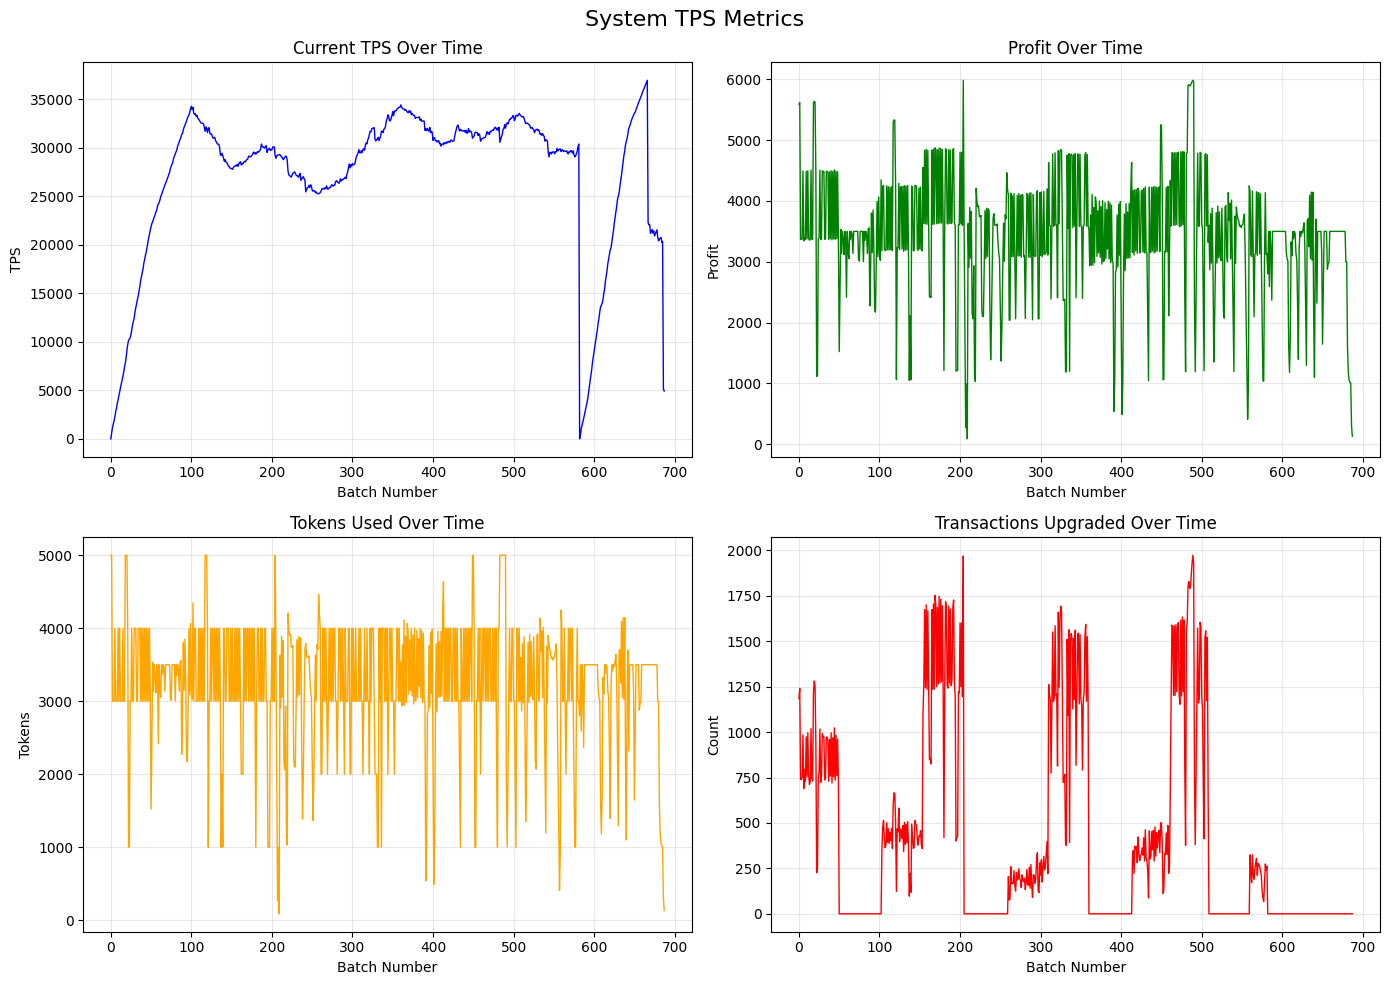


2. Plotting Incoming Transaction Rate...


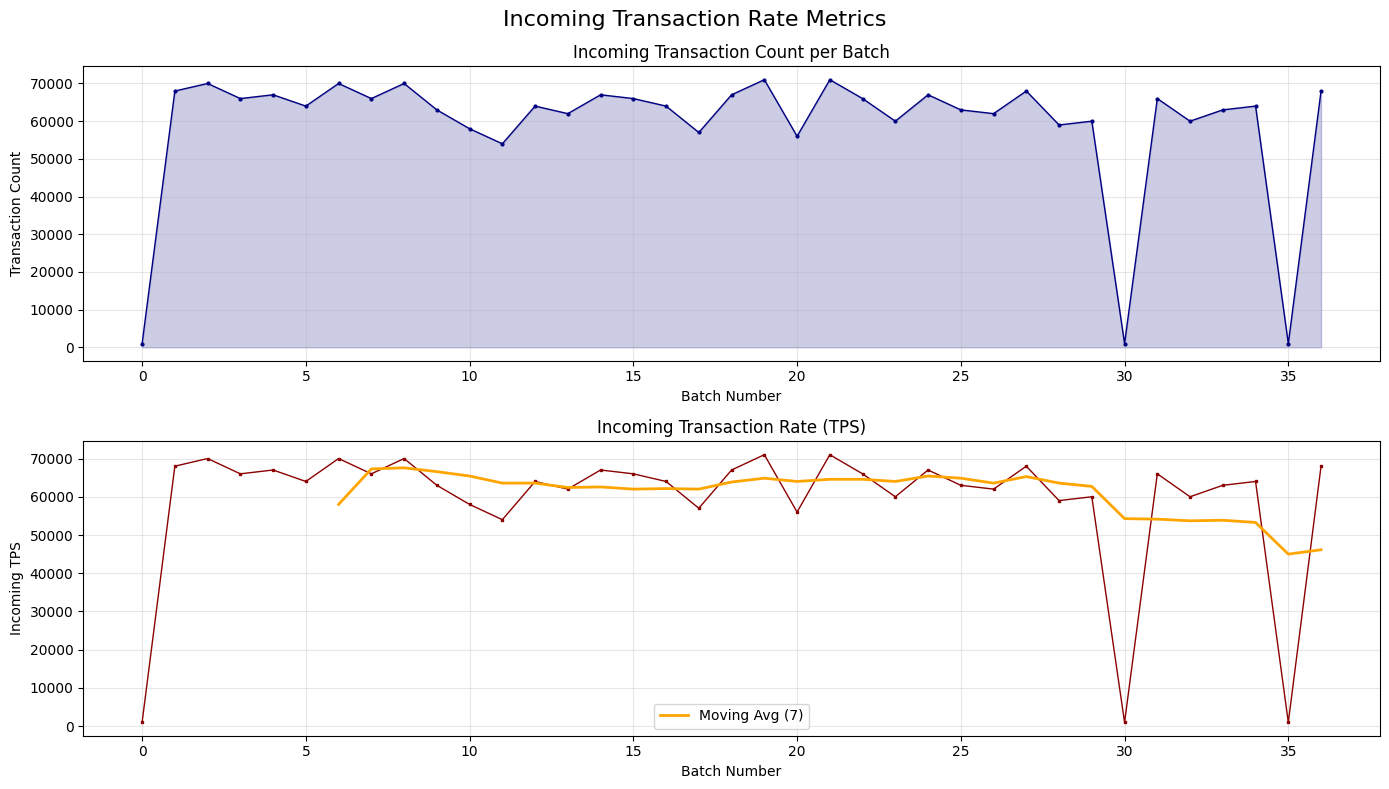


3. Plotting Backlog...


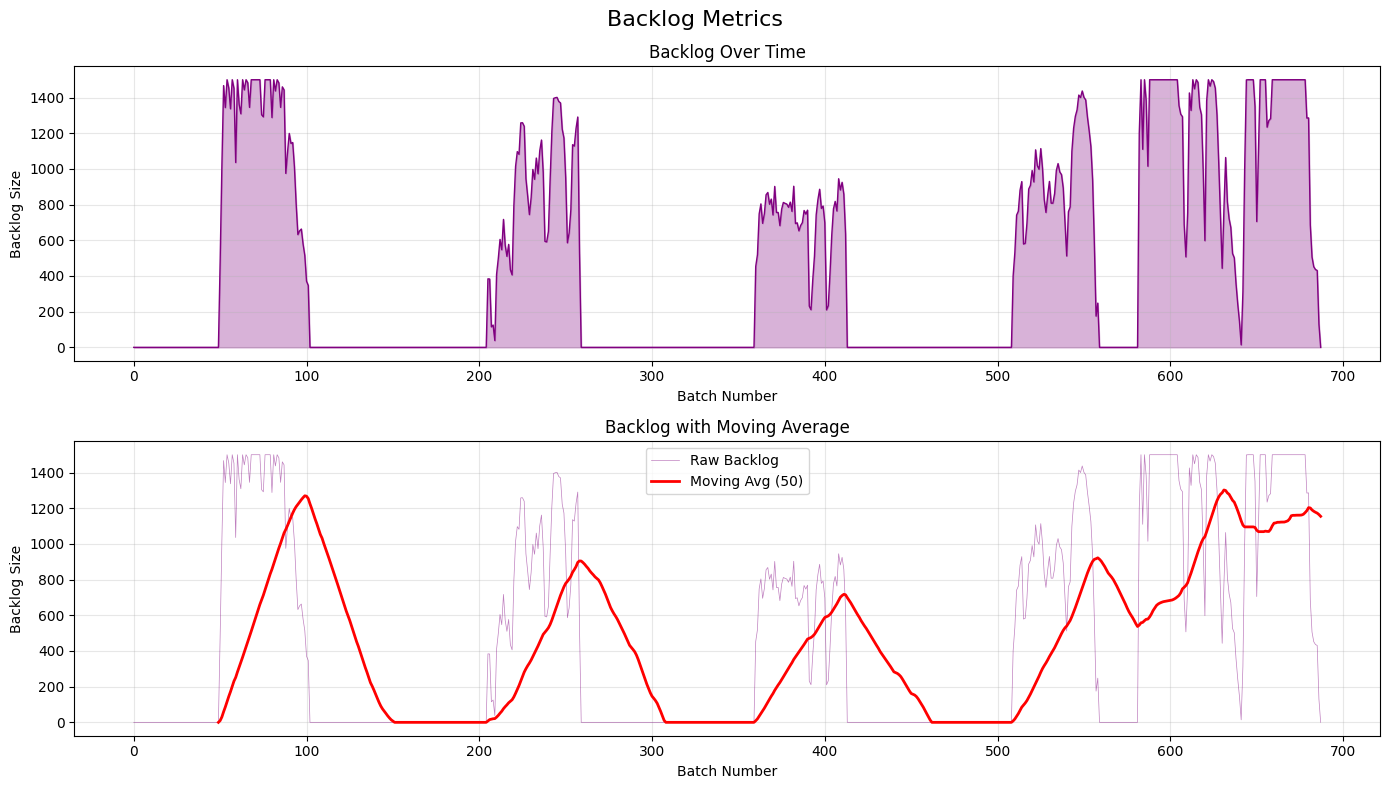


4. Plotting WriteConcern Frequency...


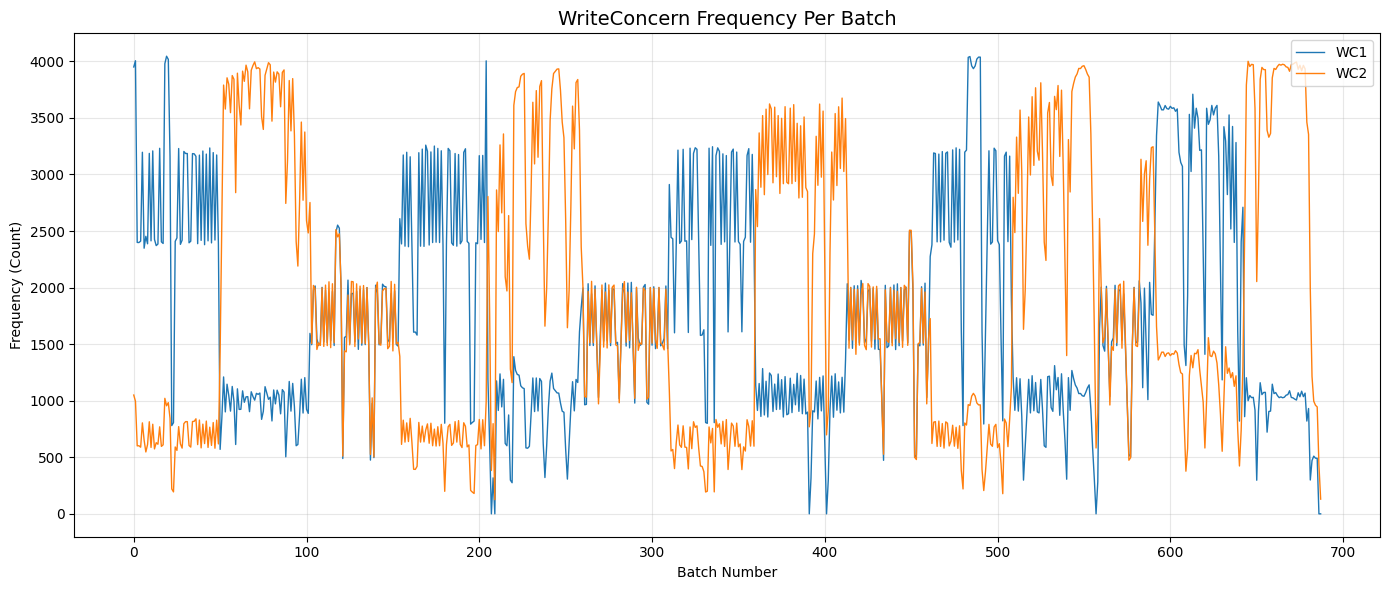


5. Plotting WriteConcern TPS...


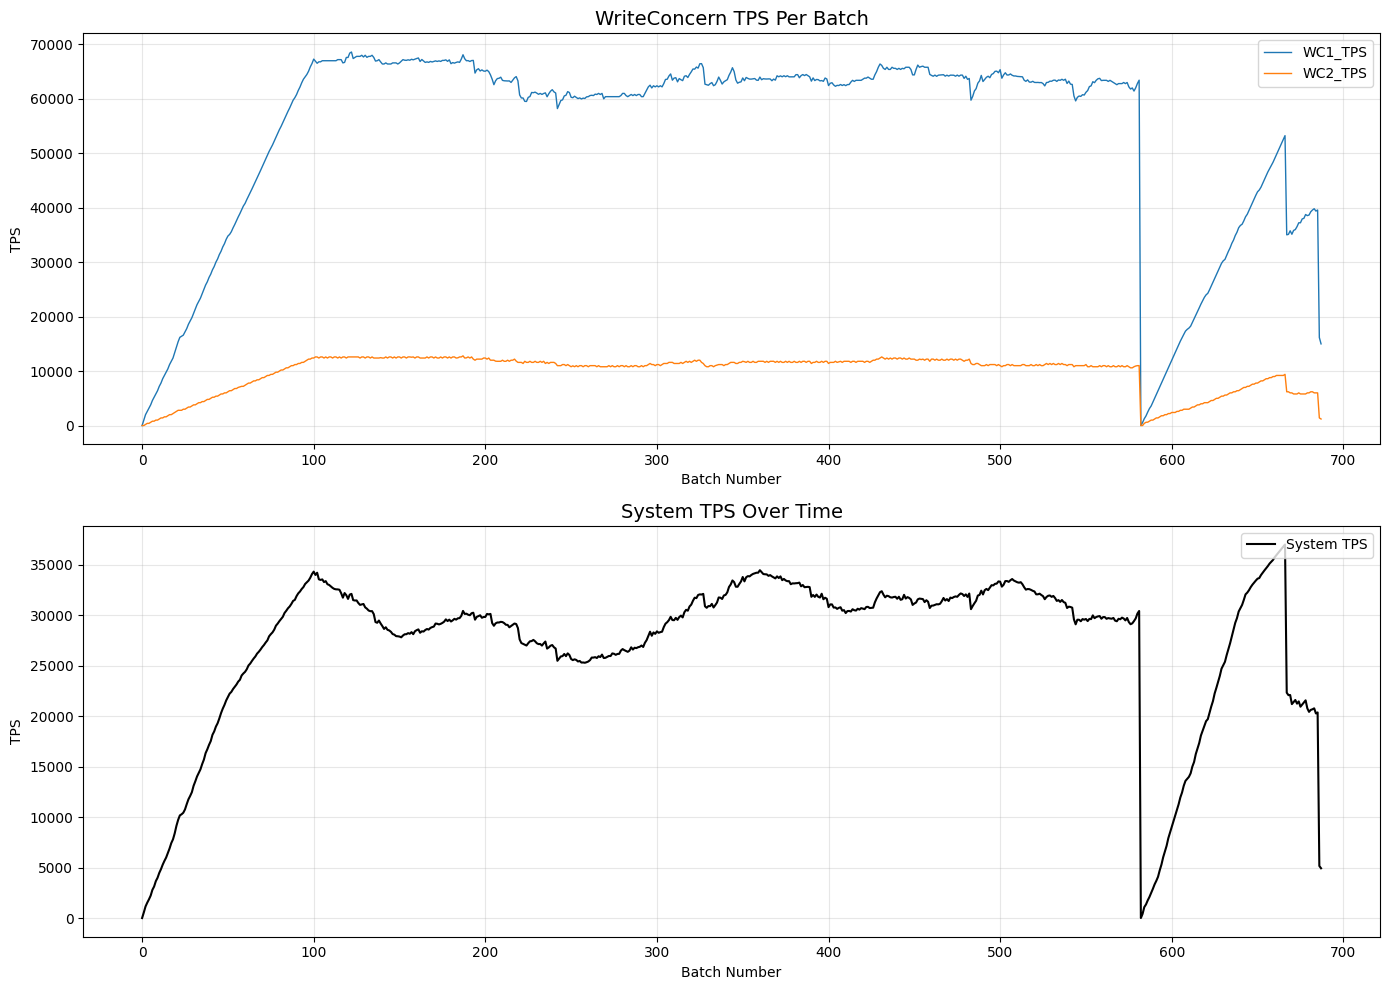


6. Plotting Final Batch Average TPS...


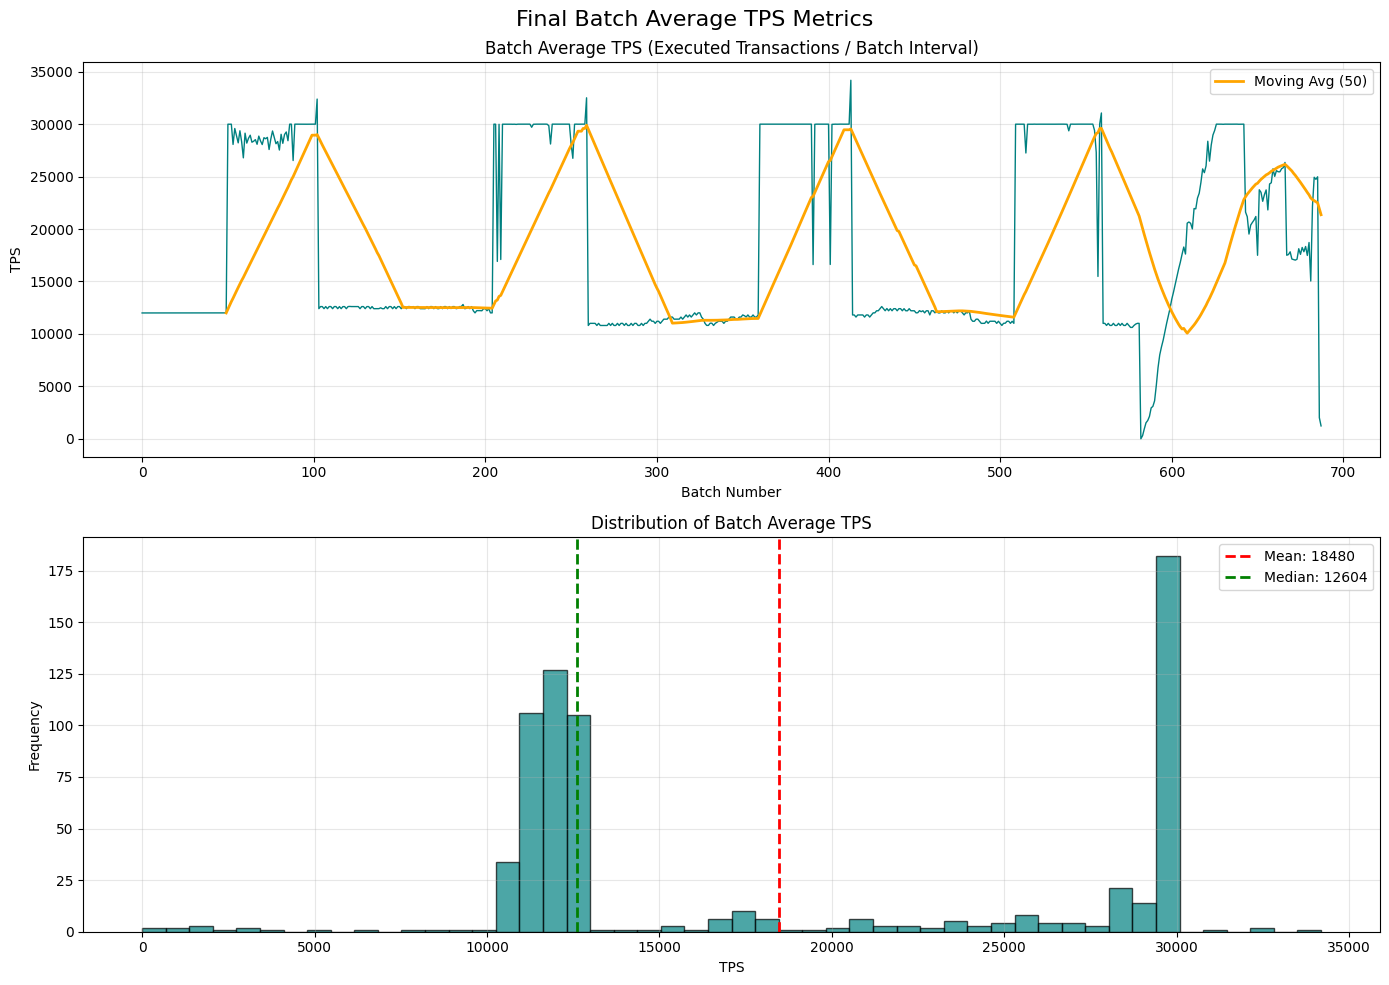


📊 Batch Average TPS Statistics:
   Mean: 18479.85
   Median: 12603.95
   Min: 0.00
   Max: 34182.01
   Std Dev: 8595.00

7. Plotting Combined Dashboard...


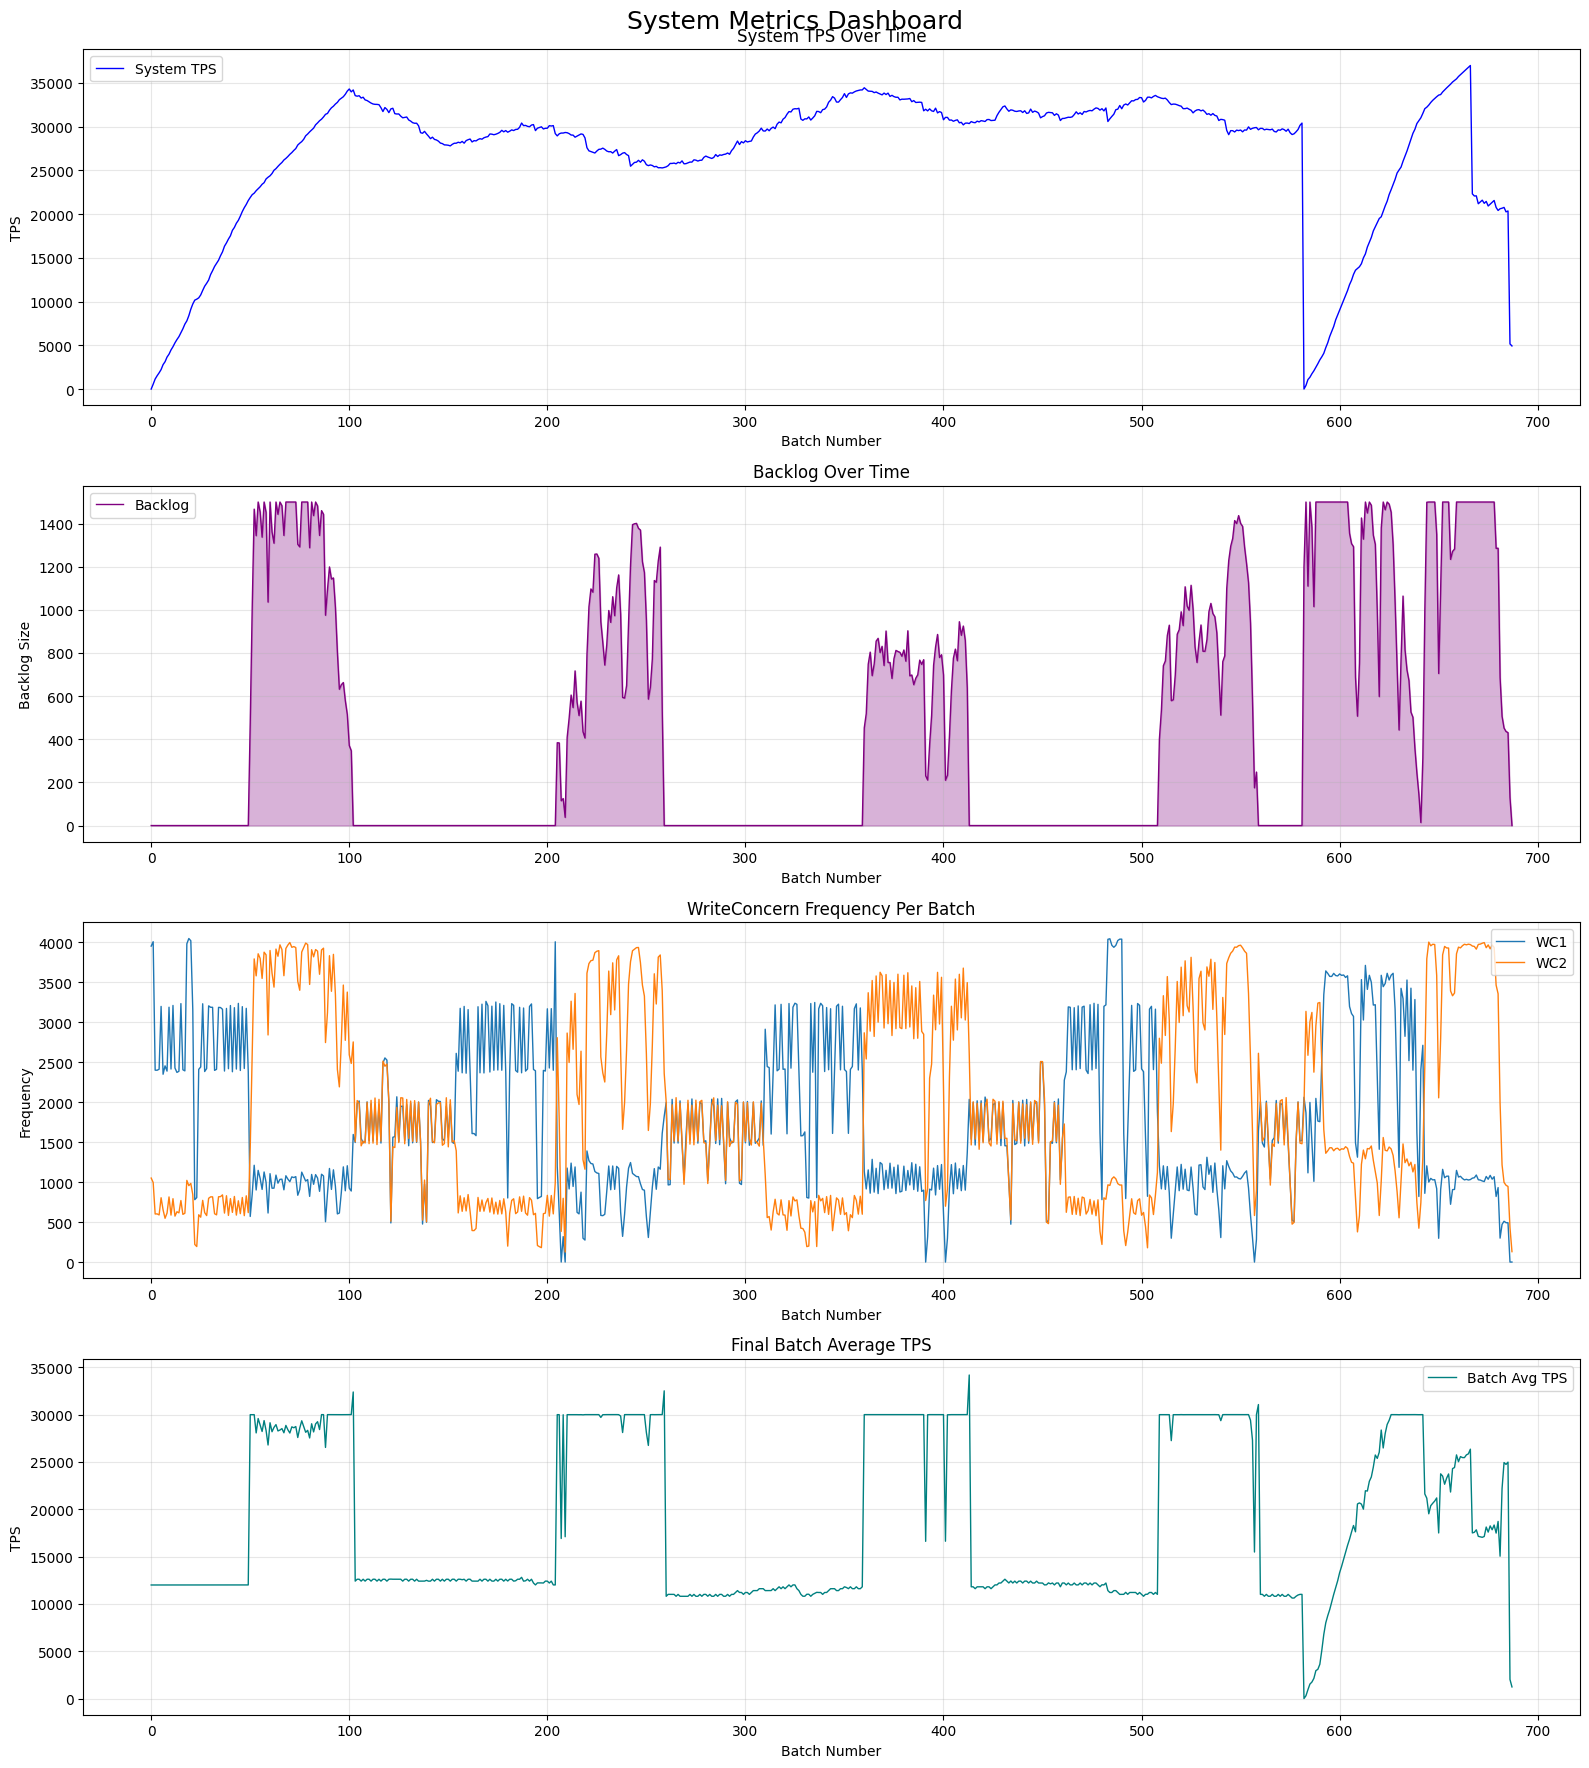


8. Plotting Stacked Area Chart...


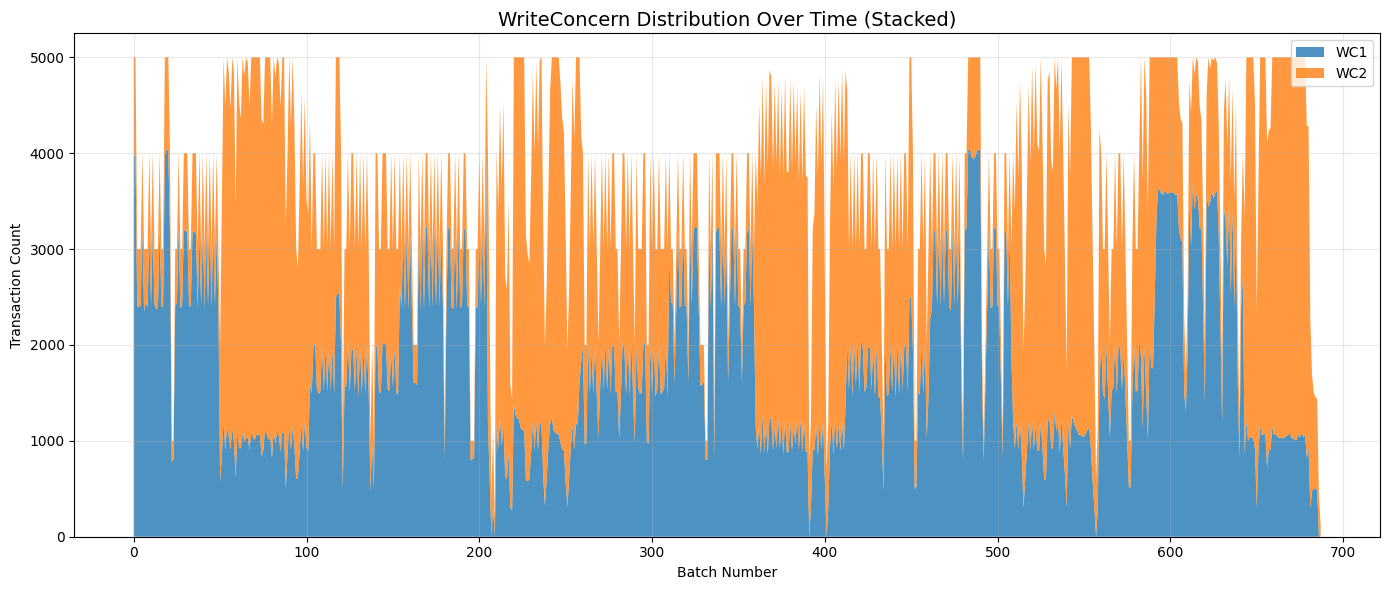


All plots generated successfully!


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set the directory where CSV files are located
CSV_DIR = "."  # Change this if CSVs are in a different directory

def plot_tps():
    """Plot system TPS metrics from tps.csv"""
    filepath = os.path.join(CSV_DIR, "tps.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('System TPS Metrics', fontsize=16)
    
    # Plot Current TPS
    axes[0, 0].plot(df.index, df['CurrentTPS'], color='blue', linewidth=1)
    axes[0, 0].set_title('Current TPS Over Time')
    axes[0, 0].set_xlabel('Batch Number')
    axes[0, 0].set_ylabel('TPS')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot Profit
    axes[0, 1].plot(df.index, df['Profit'], color='green', linewidth=1)
    axes[0, 1].set_title('Profit Over Time')
    axes[0, 1].set_xlabel('Batch Number')
    axes[0, 1].set_ylabel('Profit')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot Tokens Used
    axes[1, 0].plot(df.index, df['TokensUsed'], color='orange', linewidth=1)
    axes[1, 0].set_title('Tokens Used Over Time')
    axes[1, 0].set_xlabel('Batch Number')
    axes[1, 0].set_ylabel('Tokens')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot Transactions Upgraded
    axes[1, 1].plot(df.index, df['TransactionsUpgraded'], color='red', linewidth=1)
    axes[1, 1].set_title('Transactions Upgraded Over Time')
    axes[1, 1].set_xlabel('Batch Number')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_incoming_transaction_rate():
    """Plot incoming transaction rate from incoming_transaction_rate.csv"""
    filepath = os.path.join(CSV_DIR, "incoming_transaction_rate.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Incoming Transaction Rate Metrics', fontsize=16)
    
    # Plot Incoming Transaction Count per batch
    axes[0].plot(df.index, df['IncomingTransactionCount'], color='navy', linewidth=1, marker='o', markersize=2)
    axes[0].set_title('Incoming Transaction Count per Batch')
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('Transaction Count')
    axes[0].grid(True, alpha=0.3)
    axes[0].fill_between(df.index, df['IncomingTransactionCount'], alpha=0.2, color='navy')
    
    # Plot Incoming TPS
    axes[1].plot(df.index, df['IncomingTPS'], color='darkred', linewidth=1, marker='s', markersize=2)
    axes[1].set_title('Incoming Transaction Rate (TPS)')
    axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Incoming TPS')
    axes[1].grid(True, alpha=0.3)
    
    # Add rolling average for TPS
    window_size = min(20, len(df) // 5) if len(df) > 5 else 1
    if window_size > 1:
        df['IncomingTPS_MA'] = df['IncomingTPS'].rolling(window=window_size).mean()
        axes[1].plot(df.index, df['IncomingTPS_MA'], color='orange', linewidth=2, 
                    label=f'Moving Avg ({window_size})')
        axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_backlog():
    """Plot backlog metrics from backlog.csv"""
    filepath = os.path.join(CSV_DIR, "backlog.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Backlog Metrics', fontsize=16)
    
    # Plot Backlog over time
    axes[0].plot(df.index, df['Backlog'], color='purple', linewidth=1)
    axes[0].set_title('Backlog Over Time')
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('Backlog Size')
    axes[0].grid(True, alpha=0.3)
    axes[0].fill_between(df.index, df['Backlog'], alpha=0.3, color='purple')
    
    # Plot Backlog with rolling average
    window_size = min(50, len(df) // 10) if len(df) > 10 else 1
    if window_size > 1:
        df['Backlog_MA'] = df['Backlog'].rolling(window=window_size).mean()
        axes[1].plot(df.index, df['Backlog'], color='purple', linewidth=0.5, alpha=0.5, label='Raw Backlog')
        axes[1].plot(df.index, df['Backlog_MA'], color='red', linewidth=2, label=f'Moving Avg ({window_size})')
        axes[1].legend()
    else:
        axes[1].plot(df.index, df['Backlog'], color='purple', linewidth=1)
    axes[1].set_title('Backlog with Moving Average')
    axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Backlog Size')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_writeconcern_frequency():
    """Plot writeConcern frequency from writeconcern_frequency.csv"""
    filepath = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    # Get WC columns (exclude Timestamp and TotalInBatch)
    wc_columns = [col for col in df.columns if col.startswith('WC')]
    
    plt.figure(figsize=(14, 6))
    
    for col in wc_columns:
        plt.plot(df.index, df[col], label=col, linewidth=1)
    
    plt.title('WriteConcern Frequency Per Batch', fontsize=14)
    plt.xlabel('Batch Number')
    plt.ylabel('Frequency (Count)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_writeconcern_tps():
    """Plot writeConcern TPS from writeconcern_tps.csv"""
    filepath = os.path.join(CSV_DIR, "writeconcern_tps.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    
    # Get WC TPS columns (exclude Timestamp and SystemTPS)
    wc_tps_columns = [col for col in df.columns if col.startswith('WC') and col.endswith('_TPS')]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot individual WC TPS
    for col in wc_tps_columns:
        axes[0].plot(df.index, df[col], label=col, linewidth=1)
    
    axes[0].set_title('WriteConcern TPS Per Batch', fontsize=14)
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('TPS')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    
    # Plot System TPS for comparison
    if 'SystemTPS' in df.columns:
        axes[1].plot(df.index, df['SystemTPS'], color='black', linewidth=1.5, label='System TPS')
        axes[1].set_title('System TPS Over Time', fontsize=14)
        axes[1].set_xlabel('Batch Number')
        axes[1].set_ylabel('TPS')
        axes[1].legend(loc='upper right')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_batch_avg_tps():
    """Plot batch average TPS from final_batch_avg_tps_log.csv"""
    filepath = os.path.join(CSV_DIR, "final_batch_avg_tps_log.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    # CSV has no header, columns are: Timestamp, BatchAvgTPS
    df = pd.read_csv(filepath, header=None, names=['Timestamp', 'BatchAvgTPS'])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Final Batch Average TPS Metrics', fontsize=16)
    
    # Plot Batch Average TPS
    axes[0].plot(df.index, df['BatchAvgTPS'], color='teal', linewidth=1)
    axes[0].set_title('Batch Average TPS (Executed Transactions / Batch Interval)')
    axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('TPS')
    axes[0].grid(True, alpha=0.3)
    
    # Add rolling average
    window_size = min(50, len(df) // 10) if len(df) > 10 else 1
    if window_size > 1:
        df['BatchAvgTPS_MA'] = df['BatchAvgTPS'].rolling(window=window_size).mean()
        axes[0].plot(df.index, df['BatchAvgTPS_MA'], color='orange', linewidth=2, 
                    label=f'Moving Avg ({window_size})')
        axes[0].legend()
    
    # Plot histogram of TPS distribution
    axes[1].hist(df['BatchAvgTPS'], bins=50, color='teal', alpha=0.7, edgecolor='black')
    axes[1].set_title('Distribution of Batch Average TPS')
    axes[1].set_xlabel('TPS')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    
    # Add statistics
    mean_tps = df['BatchAvgTPS'].mean()
    median_tps = df['BatchAvgTPS'].median()
    axes[1].axvline(mean_tps, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_tps:.0f}')
    axes[1].axvline(median_tps, color='green', linestyle='--', linewidth=2, label=f'Median: {median_tps:.0f}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n📊 Batch Average TPS Statistics:")
    print(f"   Mean: {mean_tps:.2f}")
    print(f"   Median: {median_tps:.2f}")
    print(f"   Min: {df['BatchAvgTPS'].min():.2f}")
    print(f"   Max: {df['BatchAvgTPS'].max():.2f}")
    print(f"   Std Dev: {df['BatchAvgTPS'].std():.2f}")

def plot_combined_view():
    """Create a combined dashboard view"""
    fig, axes = plt.subplots(4, 1, figsize=(16, 18))
    fig.suptitle('System Metrics Dashboard', fontsize=18)
    
    # 1. TPS from tps.csv
    tps_file = os.path.join(CSV_DIR, "tps.csv")
    if os.path.exists(tps_file):
        df_tps = pd.read_csv(tps_file)
        axes[0].plot(df_tps.index, df_tps['CurrentTPS'], color='blue', linewidth=1, label='System TPS')
        axes[0].set_title('System TPS Over Time')
        axes[0].set_xlabel('Batch Number')
        axes[0].set_ylabel('TPS')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # 2. Backlog
    backlog_file = os.path.join(CSV_DIR, "backlog.csv")
    if os.path.exists(backlog_file):
        df_backlog = pd.read_csv(backlog_file)
        axes[1].plot(df_backlog.index, df_backlog['Backlog'], color='purple', linewidth=1, label='Backlog')
        axes[1].fill_between(df_backlog.index, df_backlog['Backlog'], alpha=0.3, color='purple')
        axes[1].set_title('Backlog Over Time')
        axes[1].set_xlabel('Batch Number')
        axes[1].set_ylabel('Backlog Size')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    # 3. WriteConcern Frequency
    freq_file = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if os.path.exists(freq_file):
        df_freq = pd.read_csv(freq_file)
        wc_columns = [col for col in df_freq.columns if col.startswith('WC')]
        for col in wc_columns:
            axes[2].plot(df_freq.index, df_freq[col], label=col, linewidth=1)
        axes[2].set_title('WriteConcern Frequency Per Batch')
        axes[2].set_xlabel('Batch Number')
        axes[2].set_ylabel('Frequency')
        axes[2].legend(loc='upper right')
        axes[2].grid(True, alpha=0.3)
    
    # 4. Final Batch Average TPS
    batch_tps_file = os.path.join(CSV_DIR, "final_batch_avg_tps_log.csv")
    if os.path.exists(batch_tps_file):
        df_batch_tps = pd.read_csv(batch_tps_file, header=None, names=['Timestamp', 'BatchAvgTPS'])
        axes[3].plot(df_batch_tps.index, df_batch_tps['BatchAvgTPS'], color='teal', linewidth=1, label='Batch Avg TPS')
        axes[3].set_title('Final Batch Average TPS')
        axes[3].set_xlabel('Batch Number')
        axes[3].set_ylabel('TPS')
        axes[3].legend(loc='upper right')
        axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_stacked_area_frequency():
    """Plot stacked area chart for writeConcern frequency distribution"""
    filepath = os.path.join(CSV_DIR, "writeconcern_frequency.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    wc_columns = [col for col in df.columns if col.startswith('WC')]
    
    plt.figure(figsize=(14, 6))
    plt.stackplot(df.index, [df[col] for col in wc_columns], labels=wc_columns, alpha=0.8)
    plt.title('WriteConcern Distribution Over Time (Stacked)', fontsize=14)
    plt.xlabel('Batch Number')
    plt.ylabel('Transaction Count')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("=" * 50)
    print("Plotting System Metrics")
    print("=" * 50)
    
    # Plot individual charts
    print("\n1. Plotting TPS metrics...")
    plot_tps()
    
    print("\n2. Plotting Incoming Transaction Rate...")
    plot_incoming_transaction_rate()
    
    print("\n3. Plotting Backlog...")
    plot_backlog()
    
    print("\n4. Plotting WriteConcern Frequency...")
    plot_writeconcern_frequency()
    
    print("\n5. Plotting WriteConcern TPS...")
    plot_writeconcern_tps()
    
    print("\n6. Plotting Final Batch Average TPS...")
    plot_batch_avg_tps()
    
    print("\n7. Plotting Combined Dashboard...")
    plot_combined_view()
    
    print("\n8. Plotting Stacked Area Chart...")
    plot_stacked_area_frequency()
    
    print("\n" + "=" * 50)
    print("All plots generated successfully!")
    print("=" * 50)

In [25]:
# Compute mean of System TPS for first 550 batches
import pandas as pd
import os

tps_file = os.path.join(CSV_DIR, "tps.csv")
if os.path.exists(tps_file):
    df_tps = pd.read_csv(tps_file)
    if 'CurrentTPS' in df_tps.columns:
        mean_tps_550 = df_tps['CurrentTPS'][:550].mean()
        print(f"Mean System TPS for first 550 batches: {mean_tps_550:.2f}")
    else:
        print("CurrentTPS column not found in tps.csv")
else:
    print(f"File not found: {tps_file}")

Mean System TPS for first 550 batches: 29969.92


In [24]:
# Compute mean of System TPS for batches 101 to 550 (excluding first 100)
import pandas as pd
import os

tps_file = os.path.join(CSV_DIR, "tps.csv")
if os.path.exists(tps_file):
    df_tps = pd.read_csv(tps_file)
    if 'CurrentTPS' in df_tps.columns:
        mean_tps_101_550 = df_tps['CurrentTPS'][100:550].mean()
        print(f"Mean System TPS for batches 101 to 550: {mean_tps_101_550:.2f}")
    else:
        print("CurrentTPS column not found in tps.csv")
else:
    print(f"File not found: {tps_file}")

Mean System TPS for batches 101 to 550: 31358.28


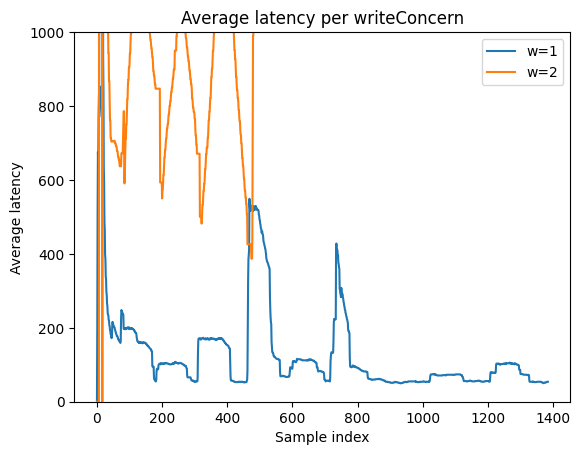

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV (no header in your file)
df = pd.read_csv("avg_latencies.csv", header=None, names=["wc", "avgLatency"])

# Create a single figure
plt.figure()

# Plot a separate line for each writeConcern
for wc, group in df.groupby("wc"):
    plt.plot(range(len(group)), group["avgLatency"], label=f"w={wc}")

plt.xlabel("Sample index")
plt.ylabel("Average latency")
plt.title("Average latency per writeConcern")
plt.legend()

# ---- Set y-axis max to 250
plt.ylim(0, 1000)

plt.show()
